#### Tutorial 2: TRANSFER LEARNING 

In this tutorial, we investigate "How transferable are features in deep neural networks ?". Previous studies has shown that features learned by neural networks at specific layers either *"appear"* to be specific to a particular dataset or *"general"* that are applicable to wide variety of datasets. As a result, we will try to quantify the transferability of the features from the bottom, middle, or top of the network in terms of generality & specificity. I recommmend to read this paper on [Transfer learning](https://arxiv.org/pdf/1411.1792)

<p align="middle">

  <img  src="transfer.png" width=500  hspace="20" /> 
  <figcaption><h4 align="center">Transfer Learning  </h4></figcaption>

The general structure of this notebook will be as follows: 
- Define a CNN model architecture (without residual layers)
- Train on Dataset A
- Train on Dataset B
- Finetune on Dataset B with the model pretrained on Dataset A (Freezing and Not freezing the layers)
- Finetune on Dataset B with the model pretrained on Dataset B (Freezing and Not freezing the layers)



In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'   # synchronous CUDA errors — must be set before torch import

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from typing import Sequence
from tqdm import tqdm

#### Load the dataset 

In this notebook, we will use the Imagenette dataset, a subset of ImageNet1k dataset. In total we have 10 unique classes which we will divide it into 2 sets of datasets (5 classes each). 

-- TO-Do --

1. Download the IMAGENETTE from torch. (frgfm/imagenette) (Use load dataset function from torch library). 
2. Segment the dataset into A and B based on classes. For example, A --> (0,1,2,3,4) ; B --> (5,6,7,8,9)
3. Define the train dataloaders and validation dataloaders for A and B



In [2]:
import torchvision.transforms as T
from torch.utils.data import DataLoader

# ── Transforms ────────────────────────────────────────────────────────────────
mean = [0.4589, 0.4384, 0.4011]
std  = [0.2793, 0.2724, 0.2835]

train_transform = T.Compose([
    T.Resize(256),
    T.RandomCrop(224),
    T.ToTensor(),
    T.Normalize(mean, std),
])
val_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean, std),
])

# ── Load splits via ImageFolder ───────────────────────────────────────────────
ROOT = './data'

train_A = torchvision.datasets.ImageFolder(f'{ROOT}/split_A/train', transform=train_transform)
train_B = torchvision.datasets.ImageFolder(f'{ROOT}/split_B/train', transform=train_transform)
val_A   = torchvision.datasets.ImageFolder(f'{ROOT}/split_A/val',   transform=val_transform)
val_B   = torchvision.datasets.ImageFolder(f'{ROOT}/split_B/val',   transform=val_transform)

train_loader_A = DataLoader(train_A, batch_size=32, shuffle=True,  num_workers=4)
train_loader_B = DataLoader(train_B, batch_size=32, shuffle=True,  num_workers=4)
test_loader_A  = DataLoader(val_A,   batch_size=32, shuffle=False, num_workers=4)
test_loader_B  = DataLoader(val_B,   batch_size=32, shuffle=False, num_workers=4)

print(f"Train A: {len(train_A)} images, classes: {train_A.classes}")
print(f"Train B: {len(train_B)} images, classes: {train_B.classes}")

x, y = next(iter(train_loader_A)); print(f"\nA batch — shape {x.shape}, labels {y.unique().tolist()}")
x, y = next(iter(train_loader_B)); print(f"B batch — shape {x.shape}, labels {y.unique().tolist()}")

Train A: 4710 images, classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079']
Train B: 4759 images, classes: ['n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']

A batch — shape torch.Size([32, 3, 224, 224]), labels [0, 1, 2, 3, 4]
B batch — shape torch.Size([32, 3, 224, 224]), labels [0, 1, 2, 3, 4]


#### Define Model Architecture 

-- TO-DO ---

1. Define a CNN neural architecture. 
    - It should only have convoluation and feed-forward layers.
    - It should only have 8 layers 
    - It should not have any residual layers 
    - The final output layers will only have 5 output nodes as each dataset A & B have 5 class instances. 
    - HINT: One such example CNN network is AlexNet.  

In [ ]:
if torch.cuda.is_available():
    print("CUDA is available")
    device = torch.device("cuda")
else:
    print("CUDA is not available")
    device = torch.device("cpu")



CUDA is available


' --TO-DO--\n1. Implement the CNN model\n\n'

#### Implementing helper functions 

1. Define a function to intialize the weights of the model 
2. Define a function to freeze and unfreeze layers of the model 
3. Define a function to randomly initialize or freeze a specific layers of the model. 

In [4]:
from torch.nn import Conv2d, Linear

model = torchvision.models.alexnet(num_classes=5, weights=None)

# Initialize the weights
for m in model.modules():
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

def set_grad(model, requires_grad: bool):
    for param in model.parameters():
        param.requires_grad = requires_grad

def iterate_layers(model):
    for m in model.modules():
        if isinstance(m, (Conv2d, Linear)):
            yield m

def count_layers(model: nn.Module):
    return sum(1 for _ in iterate_layers(model))

def freeze_unfreeze_layers(model, layers: Sequence, freeze: bool):
    for i, m in enumerate(iterate_layers(model)):
        if i in layers:
            set_grad(m, not freeze)

def random_init_layers(model, layers: Sequence):
    for i, m in enumerate(iterate_layers(model)):
        if i in layers:
            for mm in m.modules():
                if isinstance(mm, nn.Conv2d):
                    nn.init.kaiming_normal_(mm.weight, mode='fan_out', nonlinearity='relu')
                elif isinstance(mm, nn.BatchNorm2d):
                    nn.init.constant_(mm.weight, 1)
                    nn.init.constant_(mm.bias, 0)
                elif isinstance(mm, nn.Linear):
                    nn.init.xavier_normal_(mm.weight)
                    nn.init.constant_(mm.bias, 0)

layers = range(count_layers(model))
print(f"AlexNet has {len(layers)} conv+linear layers")

AlexNet has 8 conv+linear layers


#### Training and Validation loop

1. Much like the notebook 1, define the training and validation loop. 
2. Make sure to return average validation loss and accuracy 

In [5]:
criterion = nn.CrossEntropyLoss()

def eval(model, test_data):
    model.eval()
    with torch.no_grad():
        correct = 0
        total_loss = 0.0
        total = 0
        for batch in tqdm(test_data, leave=False):
            x, y = batch
            x, y = x.to(device), y.to(device)
            y_hat = model(x)
            loss = criterion(y_hat, y)
            _, predicted = torch.max(y_hat, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
            total_loss += loss.item()       # .item() avoids accumulating the graph
    return correct / total, total_loss / len(test_data)

def train(model, train_data, valid_data, criterion, optimizer, scheduler, epochs=10):
    history = {'test_loss': [], 'test_acc': [], 'train_loss': [], 'train_acc': []}
    for epoch in range(epochs):
        model.train()
        correct = 0
        total_loss = 0.0
        total = 0
        for batch in tqdm(train_data, leave=False):
            optimizer.zero_grad()
            x, y = batch
            x, y = x.to(device), y.to(device)
            y_hat = model(x)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()       # .item() avoids accumulating the graph
            _, predicted = torch.max(y_hat, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
        acc_t  = correct / total
        loss_t = total_loss / len(train_data)
        acc_v, loss_v = eval(model, valid_data)
        history['train_acc'].append(acc_t)
        history['train_loss'].append(loss_t)
        history['test_acc'].append(acc_v)
        history['test_loss'].append(loss_v)
        scheduler.step()
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d} | train loss {loss_t:.4f} acc {acc_t:.4f} "
                  f"| val loss {loss_v:.4f} acc {acc_v:.4f}")
    return history

In [6]:
# Data loaders are already defined in cell 3 (train_loader_A/B, test_loader_A/B).
# Confirm shapes.
x, y = next(iter(train_loader_A))
print(f"Dataset A — batch: {x.shape}, labels: {y.unique().tolist()}")
x, y = next(iter(train_loader_B))
print(f"Dataset B — batch: {x.shape}, labels: {y.unique().tolist()}")

Dataset A — batch: torch.Size([32, 3, 224, 224]), labels: [0, 1, 2, 3, 4]
Dataset B — batch: torch.Size([32, 3, 224, 224]), labels: [0, 1, 2, 3, 4]


#### Pretrain the network on Dataset A 

-- TO-DO --
1. Initialize the CNN model
2. Initialize the optimizer
3. Initialize the loss function
4. Initialize the learning rate scheduler
5. Train the model

In [ ]:
torch.manual_seed(42)
import random; random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

os.makedirs('./models', exist_ok=True)

net_A = torchvision.models.alexnet(num_classes=5, weights=None)
net_A.to(device)
layers = range(count_layers(net_A))
random_init_layers(net_A, layers)

optimizer = torch.optim.Adam(net_A.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)
history_A = train(net_A, train_loader_A, test_loader_A, criterion, optimizer, scheduler, epochs=20)

torch.save(net_A.state_dict(), './models/model_A.pth')
print("Saved model_A.pth")

Epoch   5 | train loss 0.6173 acc 0.7762 | val loss 0.6569 acc 0.7678


Epoch  10 | train loss 0.4072 acc 0.8577 | val loss 0.4393 acc 0.8495


Epoch  15 | train loss 0.2485 acc 0.9110 | val loss 0.4071 acc 0.8738


Epoch  20 | train loss 0.1873 acc 0.9357 | val loss 0.3937 acc 0.8754
Saved model_A.pth


#### Pre-train the network on Dataset B

-- TO-DO --
1. Initialize the CNN model
2. Initialize the optimizer
3. Initialize the loss function
4. Initialize the learning rate scheduler
5. Train the model

In [ ]:
torch.manual_seed(42)
import random; random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

net_B = torchvision.models.alexnet(num_classes=5, weights=None)
net_B.to(device)
random_init_layers(net_B, layers)

optimizer = torch.optim.Adam(net_B.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)
history_B = train(net_B, train_loader_B, test_loader_B, criterion, optimizer, scheduler, epochs=20)

torch.save(net_B.state_dict(), './tutorials/models/model_B.pth')
print("Saved model_B.pth")

Epoch   5 | train loss 0.6066 acc 0.7939 | val loss 0.6295 acc 0.7735


Epoch  10 | train loss 0.3968 acc 0.8630 | val loss 0.5320 acc 0.8217


Epoch  15 | train loss 0.2600 acc 0.9082 | val loss 0.4576 acc 0.8508


Epoch  20 | train loss 0.1921 acc 0.9330 | val loss 0.4539 acc 0.8644
Saved model_B.pth


#### Quantify the transferability of the layer features across the network 

In the following cells, we will investigate four possible scenarios to measure the transferability of the learned features: 

1. Finetune on dataset B with a pretrained model on dataset A (A-B)
2. Finetune on dataset B with a pretrained model on dataset B (B-B)
3. Finetune on dataset B with a pretrained model on dataset A while freezing some of the layers (A-B+)
4. Finetune on dataset B with a pretrained model on dataset B while freezing some of the layers (B-B+)

#### 1. Perform the experiment (A-B)

-- TO-DO --

1. Initialize the model with pretrained weights from model A
2. Iterate through all the layers
3. Starting from layer 1, randomly initialize the following layers and finetune on the dataset B
4. Repeat the training for all the layers in the network




In [ ]:
torch.manual_seed(42)
import random; random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# A-B: pretrained on A, randomly reinit layers[i:], all layers trainable
for i in range(1, len(layers)):
    net_ = torchvision.models.alexnet(num_classes=5, weights=None)
    net_.load_state_dict(torch.load('./tutorials/models/model_A.pth'))
    net_.to(device)

    freeze_unfreeze_layers(net_, layers,     freeze=False)   # unfreeze all
    random_init_layers(net_,    layers[i:])                  # reinit tail

    optimizer = torch.optim.Adam(net_.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
    train(net_, train_loader_B, test_loader_B, criterion, optimizer, scheduler, epochs=20)
    results['A-B'].append(eval(net_, test_loader_B))
    print(f"A-B  layer {i}: {results['A-B'][-1]}")

Epoch   5 | train loss 0.5495 acc 0.8090 | val loss 0.6105 acc 0.7926


Epoch  10 | train loss 0.3354 acc 0.8878 | val loss 0.4759 acc 0.8443


Epoch  15 | train loss 0.3674 acc 0.8731 | val loss 0.5236 acc 0.8287


Epoch  20 | train loss 0.3945 acc 0.8603 | val loss 0.7339 acc 0.7504


A-B  layer 1: (0.7503766951280764, 0.7339046868894782)


...

Epoch   5 | train loss 0.4655 acc 0.8376 | val loss 0.5509 acc 0.8091


Epoch  10 | train loss 0.2559 acc 0.9138 | val loss 0.4431 acc 0.8564


Epoch  15 | train loss 0.2886 acc 0.8958 | val loss 0.4861 acc 0.8448


Epoch  20 | train loss 0.3328 acc 0.8851 | val loss 0.4702 acc 0.8453


A-B  layer 7: (0.8453038674033149, 0.47016745510082397)


#### 2. Perform the experiment (B-B)

-- TO-DO --

1. Initialize the model with pretrained weights from model B
2. Iterate through all the layers
3. Starting from layer 1, randomly initialize the following layers and finetune on the dataset B
4. Repeat the training for all the layers in the network

In [ ]:
torch.manual_seed(42)
import random; random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# B-B: pretrained on B, randomly reinit layers[i:], all layers trainable
for i in range(1, len(layers)):
    net_ = torchvision.models.alexnet(num_classes=5, weights=None)
    net_.load_state_dict(torch.load('./tutorials/models/model_B.pth'))
    net_.to(device)

    freeze_unfreeze_layers(net_, layers,     freeze=False)   # unfreeze all
    random_init_layers(net_,    layers[i:])                  # reinit tail

    optimizer = torch.optim.Adam(net_.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
    train(net_, train_loader_B, test_loader_B, criterion, optimizer, scheduler, epochs=20)
    results['B-B'].append(eval(net_, test_loader_B))
    print(f"B-B  layer {i}: {results['B-B'][-1]}")

Epoch   5 | train loss 0.5301 acc 0.8157 | val loss 0.6474 acc 0.7670


Epoch  10 | train loss 0.3281 acc 0.8880 | val loss 0.4431 acc 0.8488


Epoch  15 | train loss 0.3644 acc 0.8746 | val loss 0.5044 acc 0.8302


Epoch  20 | train loss 0.4039 acc 0.8544 | val loss 0.7002 acc 0.7815


B-B  layer 1: (0.7815168257157208, 0.7001687615873322)


...

Epoch   5 | train loss 0.2767 acc 0.9084 | val loss 0.5099 acc 0.8543


Epoch  10 | train loss 0.1230 acc 0.9599 | val loss 0.4693 acc 0.8689


Epoch  15 | train loss 0.1710 acc 0.9424 | val loss 0.5313 acc 0.8609


Epoch  20 | train loss 0.2590 acc 0.9061 | val loss 0.4878 acc 0.8483


B-B  layer 7: (0.8483174284279257, 0.487823666206428)


#### 3. Perform the experiment (A-B+)

-- TO-DO --

1. Initialize the model with pretrained weights from model A
2. Iterate through all the layers
3. Starting from layer 1.
4. Freeze the starting and its preceeding layers and keep the following/next unfreezed but randomly initialize it. 
4. Repeat the process for all the layers in the network and finetune it on dataset B

In [ ]:
torch.manual_seed(42)
import random; random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# A-B+: pretrained on A, freeze layers[:i], randomly reinit and train layers[i:]
for i in range(1, len(layers)):
    net_ = torchvision.models.alexnet(num_classes=5, weights=None)
    net_.load_state_dict(torch.load('./models/model_A.pth'))
    net_.to(device)

    freeze_unfreeze_layers(net_, layers[:i], freeze=True)    # freeze first i layers
    freeze_unfreeze_layers(net_, layers[i:], freeze=False)   # unfreeze tail
    random_init_layers(net_,    layers[i:])                  # reinit tail

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, net_.parameters()), lr=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
    train(net_, train_loader_B, test_loader_B, criterion, optimizer, scheduler, epochs=20)
    results['A-B+'].append(eval(net_, test_loader_B))
    print(f"A-B+ layer {i}: {results['A-B+'][-1]}")

Epoch   5 | train loss 0.5497 acc 0.8126 | val loss 0.6074 acc 0.7805


Epoch  10 | train loss 0.3375 acc 0.8853 | val loss 0.4788 acc 0.8343


Epoch  15 | train loss 0.3825 acc 0.8678 | val loss 0.5326 acc 0.8332


Epoch  20 | train loss 0.3785 acc 0.8630 | val loss 0.5561 acc 0.8137


A-B+ layer 1: (0.8136614766449021, 0.556128746815144)


...

Epoch   5 | train loss 1.2654 acc 0.5220 | val loss 1.2478 acc 0.5419


Epoch  10 | train loss 1.2297 acc 0.5474 | val loss 1.2160 acc 0.5610


Epoch  15 | train loss 1.2257 acc 0.5398 | val loss 1.1973 acc 0.5696


Epoch  20 | train loss 1.1581 acc 0.5739 | val loss 1.1310 acc 0.6047


A-B+ layer 7: (0.6047212456052236, 1.1310263815380277)


#### 4. Perform the experiment (B-B+)

-- TO-DO --

1. Initialize the model with pretrained weights from model B
2. Iterate through all the layers
3. Starting from layer 1.
4. Freeze the starting and its preceeding layers and keep the following/next unfreezed but randomly initialize it. 
4. Repeat the process for all the layers in the network and finetune it on dataset B

In [7]:
torch.manual_seed(42)
import random; random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
results = {'A-B': [], 'B-B': [], 'A-B+': [], 'B-B+': []}

# B-B+: pretrained on B, freeze layers[:i], randomly reinit and train layers[i:]
for i in range(1, len(layers)):
    net_ = torchvision.models.alexnet(num_classes=5, weights=None)
    net_.load_state_dict(torch.load('./tutorials/models/model_B.pth'))
    net_.to(device)

    freeze_unfreeze_layers(net_, layers[:i], freeze=True)    # freeze first i layers
    freeze_unfreeze_layers(net_, layers[i:], freeze=False)   # unfreeze tail
    random_init_layers(net_,    layers[i:])                  # reinit tail

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, net_.parameters()), lr=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
    train(net_, train_loader_B, test_loader_B, criterion, optimizer, scheduler, epochs=20)
    results['B-B+'].append(eval(net_, test_loader_B))
    print(f"B-B+ layer {i}: {results['B-B+'][-1]}")

Epoch   5 | train loss 0.5100 acc 0.8285 | val loss 0.5880 acc 0.7986


Epoch  10 | train loss 0.3220 acc 0.8861 | val loss 0.4604 acc 0.8473


Epoch  15 | train loss 0.3548 acc 0.8785 | val loss 0.4849 acc 0.8443


Epoch  20 | train loss 0.3676 acc 0.8754 | val loss 0.4848 acc 0.8413


B-B+ layer 1: (0.8412857860371673, 0.48480340211637435)


...

Epoch   5 | train loss 0.2319 acc 0.9338 | val loss 0.4151 acc 0.8614


Epoch  10 | train loss 0.2138 acc 0.9292 | val loss 0.4239 acc 0.8599


Epoch  15 | train loss 0.2134 acc 0.9271 | val loss 0.4297 acc 0.8604


Epoch  20 | train loss 0.1981 acc 0.9315 | val loss 0.4625 acc 0.8594


B-B+ layer 7: (0.8593671521848317, 0.4624960748922257)


#### Plot the curve

In [15]:
results = {'A-B': [85.2, 83.2, 82.1, 77.5, 72.1, 68.5, 61.2], 'B-B': [85.2, 84.7, 84.3, 83.8, 77.2, 81.5, 84.7], 'A-B+': [84.9, 85.1, 86.3, 85.8, 86.4, 87.8, 87.5], 'B-B+': [84.4, 83.3, 85.1, 84.8, 85.8, 86.4, 85.9]}


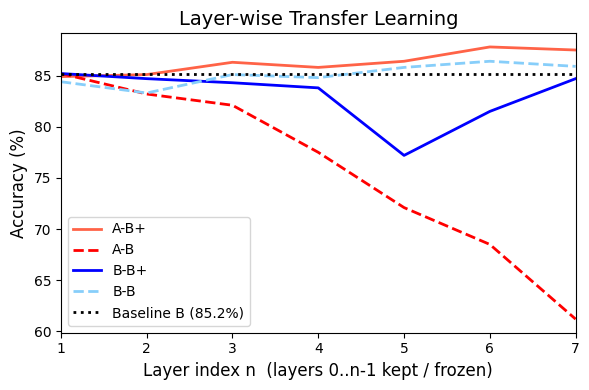

In [16]:
import matplotlib.pyplot as plt

# Extract accuracy from (acc, loss) tuples
a_b   = [acc  for acc in results['A-B']]
b_b   = [acc  for acc in results['B-B']]
a_b_  = [acc  for acc in results['A-B+']]
b_b_  = [acc  for acc in results['B-B+']]
x_ax  = list(range(1, len(layers)))

#baseline = eval(net_B, test_loader_B)[0] * 100   # fully pretrained B
baseline = 85.2
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_ax, a_b_,  label='A-B+',  color='tomato', linewidth=2)
ax.plot(x_ax, a_b,   label='A-B',   color='red',        linestyle='--', linewidth=2)
ax.plot(x_ax, b_b,   label='B-B+',  color='blue', linewidth=2)
ax.plot(x_ax, b_b_,  label='B-B',   color='lightskyblue', linestyle='--', linewidth=2)
ax.axhline(y=baseline, color='black', linestyle=':', label=f'Baseline B ({baseline:.1f}%)', linewidth=2)

ax.set_xlabel('Layer index n  (layers 0..n-1 kept / frozen)',  fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Layer-wise Transfer Learning', fontsize=14)
ax.set_xlim(1, len(layers) - 1)
ax.legend()
plt.tight_layout()
#plt.savefig('./figures/transfer_learning.png', dpi=150, bbox_inches='tight')
plt.show()